In [1]:
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
import matplotlib as mpl
import time as time
import pandas as pd
import math
import copy
import os

# Nice colours
colorsBlue = ['#b3e5fc', '#0091ea']
colorsRed = ['#f18e86', '#e83b47']
colorsYellow = ['#fb9d32', '#fec787']
colorsPurple = ['#d69bc5' ,'#a8509f']
colorsGreyOrange = ['#c3c3c3', '#f8a834']
colors = [colorsBlue, colorsRed, colorsYellow, colorsPurple, colorsGreyOrange]

# Nice cmap
import matplotlib.colors as mcolors
cmap = mcolors.LinearSegmentedColormap.from_list('custom_cmap', [colors[0][1], 'white', colors[1][1]])

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

from utils.dataset import GeneralDataset
from utils.network import MODEL
from utils.graphs import analyse_connectivity
from utils.plots import *

In [3]:
# basic settings
encode_num = 4
decode_num = 4
k = encode_num
hidden_num = 32
LAYER_NUM = 3
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

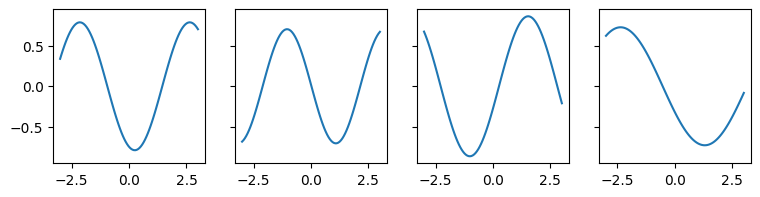

In [ ]:
seed = 145
np.random.seed(seed)

RUN_TYPE = 'nonlinear' # 'linear' for f(x) = x, or 'nonlinear' for randomly generated f(x)
folder = f'results'
os.makedirs(folder, exist_ok = True)

if RUN_TYPE == 'linear':
	def morph(x):
		return x
	common_settings = {'L2' : 1e-4, 'bias' : False, 'nonlinear' : False, 'hidden_layer' : LAYER_NUM} # adding L2 here prevents runaway weight dynamics
else:
	amps = 0.7 + 0.3 * np.random.rand(encode_num) # * ((np.random.rand(encode_num) > 0) - 0.5)
	fres = 0.4 + 1.4 * np.random.rand(encode_num) # 0.4, 0.4 for N8 and N16
	phis = 2 * np.pi * np.random.rand(encode_num)
	def morph(x):
		return amps * np.sin(fres * x + phis)
	common_settings = {'L2' : 1e-4, 'bias' : True, 'nonlinear' : True, 'hidden_layer' : LAYER_NUM}

# plot to-be-learned functions
fig, axes = plt.subplots(1, encode_num, figsize = (9, 2), sharex = True, sharey = True)
xx = np.linspace(-3, 3, 100)
yy = np.array([morph([x] * encode_num) for x in xx])
for i in range(encode_num):
	axes[i].plot(xx, yy[:, i])

In [16]:
# training and test datasets
train_dataset = GeneralDataset(encode_num = encode_num, mapfun = morph, num_samples = 1000)
test_dataset = GeneralDataset(encode_num = encode_num, mapfun = morph, num_samples = 1000)
train_dataloader = DataLoader(train_dataset, batch_size = 200)

lr = 1e-3
wd = 0 # using explicit L2 regularisation
num_epochs = 10000

settings = [{'name' : 'Noise0', 'noise_coef' : 0.1, 'noise_expt' : 0},
			{'name' : 'Noise1', 'noise_coef' : 0.1, 'noise_expt' : 1},
			{'name' : 'Noise2', 'noise_coef' : 0.1, 'noise_expt' : 2},
			{'name' : 'L2'},
			{'name' : 'L1', 'L1': 1e-3},
			{'name' : 'Act', 'Act' : 1e-3},
			{'name' : 'WeightedAct', 'WeightedAct' : 1e-3},
			{'name' : 'WeightedActSigmoid', 'WeightedAct' : 1e-3, 'use_sigmoid' : True},
			{'name' : 'WeightedActTanh', 'WeightedAct' : 1e-3, 'use_tanh' : True},
			]

In [17]:
for setting in settings:
    file_name = setting['name']
    folder = f'results_{RUN_TYPE}/{file_name}'
    os.makedirs(folder, exist_ok = True)
    print(f'running setting {file_name}...')
    
    model = MODEL(encode_num = encode_num,
              decode_num = decode_num,
              hidden_num = hidden_num,
              **(setting | common_settings))
    model.to(device)
    
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr = lr, weight_decay = wd)

    # Training loop
    losses = []
    model.train()
    for epoch in range(num_epochs):
        losses.append(model.fit(train_dataloader, train_dataset, test_dataset, optimizer, criterion, device))
        print(f'epoch {epoch:07d}, test loss {losses[-1][0]:.5f}, valid vloss {losses[-1][1]:.5f}, L2 norm {losses[-1][3]:.5f}', end = '\r')
    losses = np.array(losses)
    print()

    # plot, analyse, and save miscellaneous stuff
    plot_test(model, test_dataset, device, morph, folder, f'scatter')
    plot_loss(losses, folder, f'losses')
    WMATS, EIG_RAW, EIG, IDX = analyse_connectivity(model, k = encode_num)
    # plot_spectrum(EIG_RAW, folder, f'spectrum_raw')
    plot_spectrum(EIG, folder, f'spectrum')
    plot_connectivity(WMATS, EIG, IDX, k, cmap, folder, f'connectivity')
    torch.save(model, f'{folder}/model.pth')
    with open(f'{folder}/losses.npy', 'wb') as f:
        np.save(f, losses)

running setting Noise0...
epoch 0009999, test loss 0.00266, valid vloss 0.00265, L2 norm 43.72057
min - max : -1.758 - 1.601
min - max : -0.655 - 0.910
min - max : -0.523 - 0.661
min - max : -0.147 - 0.195
running setting Noise1...
epoch 0009999, test loss 0.00356, valid vloss 0.00359, L2 norm 36.60969
min - max : -1.014 - 0.857
min - max : -0.544 - 0.766
min - max : -0.445 - 0.499
min - max : -0.364 - 0.461
running setting Noise2...
epoch 0009999, test loss 0.00227, valid vloss 0.00240, L2 norm 28.41885
min - max : -0.683 - 0.619
min - max : -0.462 - 0.679
min - max : -0.487 - 0.406
min - max : -0.714 - 0.698
running setting L2...
epoch 0009999, test loss 0.00010, valid vloss 0.00012, L2 norm 22.38934
min - max : -0.830 - 0.635
min - max : -0.412 - 0.533
min - max : -0.308 - 0.377
min - max : -0.592 - 0.772
running setting L1...
epoch 0009999, test loss 0.06876, valid vloss 0.07195, L2 norm 10.39392
min - max : -0.959 - 0.987
min - max : -0.989 - 0.854
min - max : -0.989 - 0.958
min -